# Double Pendulum Forecasting with Recurrent Neural Networks


This notebook uses simulated double pendulum trajectories to train and assess a recurrent neural network for short‑term and long‑horizon forecasting of the system’s dynamics.

**Note :** This notebook uses equal masses (m1 = m2 = 1) for clarity and reproducibility.
The modelling notebook explores a different mass configuration.

In [ ]:
# Preamble :

# Import required libraries :

# Libraries for the mathematics
import numpy as np
from scipy.integrate import solve_ivp

# Libraries for Neural Network :

# Build network architecture
import tensorflow as tf
from tensorflow import keras

# Prevent Model Overfitting
from keras.callbacks import EarlyStopping

# L2 penalty term used to improve generalisation
# by limiting weight growth
from keras.regularizers import l2

#Import tqdm for progress bar
from tqdm import tqdm

# Libraries for plotting and style :
import matplotlib.pyplot as plt
import matplotlib.style
import matplotlib as mpl

# Set default figure size
mpl.rcParams["legend.frameon"] = False
mpl.rcParams['figure.dpi']     = 200

#Double Pendulum System Set Up

**Physical Parameters and time domain :**

In [ ]:
# Initialise parameters for double pendulum system

# Initial Lengths
L1, L2 = 1., 1.

# Inital masses
m1, m2 = 1., 1.

# Define Gravitational acceleration (m/s^2)
g = 9.81

# Define time domain
tmax, dt = 50, 0.1
t = np.arange(0,tmax+dt, dt)


# Define max_vals: physical scaling ranges for
# [x1, y1, x2, y2, vx1, vy1, vx2, vy2]
max_vals = np.array([2.0, 2.0, 2.0, 2.0, 5.0, 5.0, 5.0, 5.0])



**Core functions for the double pendulum system :**

In [ ]:
def double_pendulum_ode(t, z, L1, L2, m1, m2, g):
    """
    Calculates the time derivatives for the double pendulum system.
    State vector z = [theta1, omega1, theta2, omega2].
    """

    theta1, omega1, theta2, omega2 = z

    # Difference in angular positions
    delta_theta = theta1 - theta2

    # Define variables which store trigonometic functions of theta
    cos_delta =  np.cos(delta_theta)
    sin_delta =  np.sin(delta_theta)
    sin_theta1  =  np.sin(theta1)
    sin_theta2  =  np.sin(theta2)

    # Shared terms in angular acceleration:

    # Gravitational term
    g_term = (m1 + m2) * g * sin_theta1

    # Coupling term
    coupling = m2 * cos_delta * sin_delta

    # common denominator term
    eta = cos_delta**2* m2 - (m1 + m2)


    # Angular accelerations
    d_omega1 = (   L1  * coupling  *  omega1**2 + L2 * m2
                       * sin_delta *  omega2**2
                       - m2 * g    *  cos_delta * sin_theta2
                       + g_term)   /  (L1 * eta)

    d_omega2 = -(  L2 * coupling  * omega2**2 +  L1 * (m1 + m2)
                      * sin_delta * omega1**2 +  g_term
                      * cos_delta - (m1 + m2) *  g *
                      sin_theta2) / (L2 * eta)

            # Output the angluar velocity (omega's)
            # and angular acceleration (omega dot's)

    return omega1, d_omega1, omega2, d_omega2


# Converts one timestep of angular state to Cartesian state.

def to_cartesian(theta1, omega1, theta2, omega2, L1, L2):
    """ Converts the polar coordinates (theta and omega)
        into cartesian coordinates(x,y) and velocities (vx,vy).

        Returns x1, y1, x2, y2, vx1, vy1, vx2, vy2.
    """
    x1 =  L1  * np.sin(theta1)
    y1 = -L1  * np.cos(theta1)

    x2 =  x1  + L2 * np.sin(theta2)
    y2 =  y1  - L2 * np.cos(theta2)

    vx1 = L1  * np.cos(theta1) * omega1
    vy1 = L1  * np.sin(theta1) * omega1

    vx2 = vx1 + L2 * np.cos(theta2) * omega2
    vy2 = vy1 + L2 * np.sin(theta2) * omega2

    return x1, y1, x2, y2, vx1, vy1, vx2, vy2


# Multi-Trajectory Dataset Pipeline

In [ ]:
# Simulating a Single Trajectory :

def simulate_trajectory(z0, t):
    """
    Simulates a single double pendulum trajectory for given initial conditions z0.
    Returns an array of shape (N, 4):
    [theta1, omega1, theta2, omega2] for each timestep.
    """
    sol = solve_ivp(
        double_pendulum_ode,
        (t[0], t[-1]),
        z0,
        t_eval=t,
        args=(L1, L2, m1, m2, g)
    )
    return sol.y.T  # transforms shape of data from (4, N) to (N, 4)



# Converting Angular Trajectories :

def to_cartesian_state(traj):
    """
    Converts the entire angular trajectory [theta1, omega1,
    theta2, omega2] into Cartesian coordinates and velocities.

    traj shape: (N, 4)
    Returns array of shape (N, 8):
    [x1, y1, x2, y2, vx1, vy1, vx2, vy2] for each timestep
    """
    cart = []
    for theta1, omega1, theta2, omega2 in traj:
        x1, y1, x2, y2, vx1, vy1, vx2, vy2 = to_cartesian(theta1, omega1, theta2,
                                                  omega2, L1, L2)
        cart.append([x1, y1, x2, y2, vx1, vy1, vx2, vy2])
    return np.array(cart)



# Scaling and Normalisation :

def scale_state(data):
    """
    Normalises Cartesian positions and velocities.
    Uses fixed physical ranges for stability across trajectories.
    data shape: (N, 8)
    """
    return data / max_vals



# Building Sliding‑Window Sequences :

def build_sequences(data, seq_len):
    """
    Converts a trajectory into overlapping input/output pairs.

    X: shape (num_windows, seq_len, 8)
    y: shape (num_windows, 8)
    """
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)



# Sampling Random Initial Conditions :

def sample_initial_conditions(n_traj):
    """
    Samples n_traj random initial conditions.
    This replaces a single z0, e.g z0 = [pi/2, 0, pi/2, 0].
    """
    inits = []
    for _ in range(n_traj):
        theta1 = np.random.uniform(-np.pi, np.pi)
        theta2 = np.random.uniform(-np.pi, np.pi)
        omega1 = np.random.uniform(-1.0, 1.0)
        omega2 = np.random.uniform(-1.0, 1.0)
        inits.append([theta1, omega1, theta2, omega2])
    return inits



# Building the Multi‑Trajectory Dataset :

def build_multi_trajectory_dataset(n_traj, seq_len):
    """
    Generates a full dataset from multiple simulated trajectories.

    Returns:
    X_all: (total_samples, seq_len, 8)
    y_all: (total_samples, 8)
    """
    X_all, y_all = [], []

    inits = sample_initial_conditions(n_traj)

    for idx, z0 in enumerate(inits):
        print(f"Simulating trajectory {idx+1}/{n_traj}...")

        # Simulate angular trajectory
        traj = simulate_trajectory(z0, t)

        # Convert to Cartesian
        traj_cart = to_cartesian_state(traj)

        # Scale trajectory independently
        traj_scaled = scale_state(traj_cart)

        # Build sequences
        X_seq, y_seq = build_sequences(traj_scaled, seq_len)

        X_all.append(X_seq)
        y_all.append(y_seq)

    # Concatenate all trajectories
    X_all = np.vstack(X_all)
    y_all = np.vstack(y_all)

    # Check final dataset dimensions after concatenating all trajectories
    print(f"\nFinal dataset shapes:")
    print(f"X_all (all input sequences): {X_all.shape}")
    print(f"y_all (all target vectors):  {y_all.shape}")

    return X_all, y_all


**Generate the Multi-Trajectory Dataset:**

In [ ]:
# Define input window length (~5s of history)
seq_len = 50
X, y = build_multi_trajectory_dataset(n_traj=20, seq_len=seq_len)


Simulating trajectory 1/20...
Simulating trajectory 2/20...
Simulating trajectory 3/20...
Simulating trajectory 4/20...
Simulating trajectory 5/20...
Simulating trajectory 6/20...
Simulating trajectory 7/20...
Simulating trajectory 8/20...
Simulating trajectory 9/20...
Simulating trajectory 10/20...
Simulating trajectory 11/20...
Simulating trajectory 12/20...
Simulating trajectory 13/20...
Simulating trajectory 14/20...
Simulating trajectory 15/20...
Simulating trajectory 16/20...
Simulating trajectory 17/20...
Simulating trajectory 18/20...
Simulating trajectory 19/20...
Simulating trajectory 20/20...

Final dataset shapes:
X_all (all input sequences): (9020, 50, 8)
y_all (all target vectors):  (9020, 8)


> **Note on sequence length and sample count**  
>  
> The sequence length is set to **50**, meaning the RNN receives the previous  
> 50 timesteps (≈5 seconds of simulated motion) to predict the next state.  
> This window size provides enough temporal context for the model to capture  
> the short‑term dynamics of the double pendulum while remaining computationally  
> lightweight.  
>  
> For each trajectory of 501 timesteps, the sliding‑window procedure produces:  
>  
>


> 501 - 50 = 451   usable input–target pairs
>

  
>  
> When generating **20 independent trajectories** with different initial  
> conditions, this results in approximately:  
>  
>


> 20 * 451  = 9020  training samples
>
  
>  
> This multi‑trajectory dataset provides diverse dynamical regimes and  
> significantly improves model generalisation compared to training on a  
> single trajectory.



##Train / Validation / Test Split (Time‑Based)



 The mulit-trajectory dataset is split chronologically to preserve temporal structure. The first 80% of samples are used for training, the next 10% for validation, and the final 10% for testing.

In [ ]:
# Time-based data split
train_ratio = 0.8
valid_ratio = 0.1 # remaing 0.1 is used for the test set

# total number of sequence samples available
N = len(X)

train_end = int(N * train_ratio)
valid_end = int(N * (train_ratio + valid_ratio))

X_train, y_train = X[:train_end], y[:train_end]
X_valid, y_valid = X[train_end:valid_end], y[train_end:valid_end]
X_test,  y_test  = X[valid_end:], y[valid_end:]


# Check dimensions of split data
print(
    f"Training set:   X={X_train.shape}, y={y_train.shape}\n"
    f"Validation set: X={X_valid.shape},  y={y_valid.shape}\n"
    f"Test set:       X={X_test.shape},  y={y_test.shape}"
)

Training set:   X=(7216, 50, 8), y=(7216, 8)
Validation set: X=(902, 50, 8),  y=(902, 8)
Test set:       X=(902, 50, 8),  y=(902, 8)


# Baseline Model Architecture

The forecasting model consists of a single LSTM layer followed by fully‑connected
layers. The LSTM processes a 50‑step input sequence (≈5 seconds of motion) and
outputs a single hidden state used to predict the next state of the system.

Dropout layers are included to improve generalisation, which is important when
modelling chaotic dynamics. The final dense layer outputs the eight Cartesian
state variables of the double pendulum at the next timestep:
[x1, y1, x2, y2, vx1, vy1, vx2, vy2].


In [ ]:
# Recurrent neural network for short‑term forecasting
model = keras.models.Sequential()

# Input layer: sequences of length 50 with 8 features per timestep
model.add(keras.layers.Input(shape=(seq_len, 8)))

# LSTM layer: extracts temporal structure from the input sequence
model.add(keras.layers.LSTM(
    64,
    activation='tanh',
    return_sequences=False
))

# Regularisation to improve generalisation on chaotic dynamics
model.add(keras.layers.Dropout(0.2))

# Fully‑connected layers to map the LSTM state to the output space
model.add(keras.layers.Dense(64, activation='tanh'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(32, activation='tanh'))

# Output layer: predict the next state (8 values)
model.add(keras.layers.Dense(8, activation='linear'))

# Compile the model
model.compile(
    loss='mean_squared_error',
    optimizer='adam',
    metrics=['mean_absolute_error']
)

# Display model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,192 (98.41 KB)

 Trainable params: 25,192 (98.41 KB)

 Non-trainable params: 0 (0.00 B)

# Baseline Model Training and Optimisation

The model is trained using early stopping to prevent overfitting, which is
especially important for chaotic systems like the double pendulum. Since small
errors can grow rapidly in chaotic dynamics, the model may begin to memorise
trajectory‑specific patterns rather than learning the underlying behaviour. Early
stopping monitors the validation loss and halts training when no further
improvement is observed, restoring the best-performing weights.


In [ ]:
# Early stopping to prevent overfitting on chaotic dynamics
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    shuffle=False,  # preserve temporal order
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - loss: 0.1322 - mean_absolute_error: 0.2473 - val_loss: 0.0348 - val_mean_absolute_error: 0.1278
Epoch 2/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0836 - mean_absolute_error: 0.1896 - val_loss: 0.0205 - val_mean_absolute_error: 0.1010
Epoch 3/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0650 - mean_absolute_error: 0.1691 - val_loss: 0.0160 - val_mean_absolute_error: 0.0933
Epoch 4/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0545 - mean_absolute_error: 0.1573 - val_loss: 0.0137 - val_mean_absolute_error: 0.0886
Epoch 5/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0476 - mean_absolute_error: 0.1484 - val_loss: 0.0111 - val_mean_absolute_error: 0.0800
Epoch 6/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0429 - mean_absolute_error: 0.1416 - val_loss: 0.0111 - val_mean_absolute_error: 0.0805
Epoch 7/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0403 - mean_absolute_er

# Baseline Model Evaluation

The trained model is evaluated on the held‑out test set to assess its ability to
generalise to unseen trajectories. The test loss and mean absolute error provide
a quantitative measure of forecasting accuracy. The training and validation loss
curves are plotted to verify stable optimisation and the effectiveness of early
stopping.


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0090 - mean_absolute_error: 0.0614
Test Loss: 0.0090,  Mean Absolute Error: 0.0614


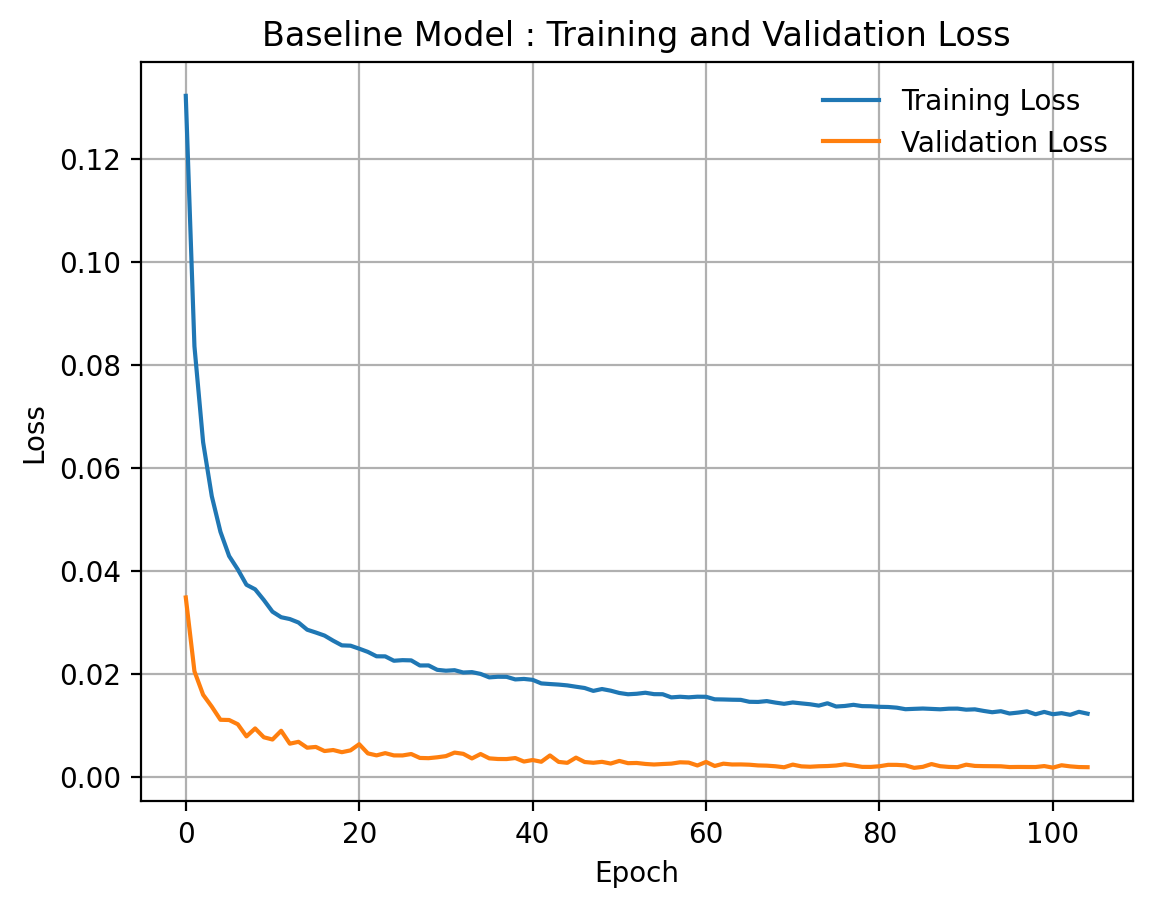

In [ ]:
# Evaluate model on the test set
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Loss: {test_loss:.4f},  Mean Absolute Error: {test_mae:.4f}")

# Plot training and validation loss curves
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline Model : Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


The training and validation loss curves show stable optimisation behaviour. The validation loss remains below the training loss due to dropout being active during training and the sensitivity of chaotic systems to noise. The consistent gap indicates that the model is not overfitting and is learning a generalisable representation of the dynamics.

# Short Horizon Forecasting

Short‑horizon forecasting evaluates the model’s ability to predict the next few
timesteps of the system when given an initial input sequence. The model is used
autoregressively: each predicted state is fed back as input to generate the next
prediction. This allows the network to simulate the system forward in time for a
small number of steps, providing a direct measure of short‑term predictive
accuracy.


**Prediction Function**

In [ ]:
# Autoregressive prediction for n future steps
def predict_future_positions(model, initial_sequence, n_steps, seq_len):
    """
    Predicts n future states autoregressively using the trained model.

    initial_sequence: array of shape (seq_len, 8)
    n_steps: number of future steps to predict
    seq_len: length of input window (50)
    """
    sequence = list(initial_sequence)

    for _ in range(n_steps):
        # Prepare input window
        input_seq = np.array(sequence[-seq_len:]).reshape(1, seq_len, 8)

        # Predict next state
        pred = model.predict(input_seq, verbose=0)[0]

        # Append prediction
        sequence.append(pred.tolist())

    # Return only the predicted future states
    return np.array(sequence[-n_steps:])

**Forecast Preparation**

In [ ]:
# Short-horizon prediction (20 steps)

# Select a test sequence and its true future values
initial_seq = X_test[-1]              # shape (50,8)
true_future = y_test[-20:]            # the next 20 true steps (shape 20×8)

# Predict 20 future steps (~2 seconds)
pred_future_scaled = predict_future_positions(
    model,
    initial_seq,
    n_steps=20,
    seq_len=seq_len
)

# Unscale both true and predicted (inverse transform)
pred_future = pred_future_scaled * max_vals
true_future_unscaled = true_future * max_vals

# Extract Cartesian positions
true_x1, true_y1 = true_future_unscaled[:, 0], true_future_unscaled[:, 1]
true_x2, true_y2 = true_future_unscaled[:, 2], true_future_unscaled[:, 3]

pred_x1, pred_y1 = pred_future[:, 0], pred_future[:, 1]
pred_x2, pred_y2 = pred_future[:, 2], pred_future[:, 3]

# Time axis for the 20-step forecast
t_future = np.arange(20)


In [ ]:
# TEST PRINT BLOCK TO CHECK PREDICTIONS ARE HAPPENING CORRECTLY

# Print predicted states
def show_future_positions(unscaled_states):
    for i, state in enumerate(unscaled_states):
        print(f"t = t0 + {(i+1)}Δt : {state}")

show_future_positions(true_future_unscaled)

t = t0 + 1Δt : [ 0.99898194  0.04511188  1.00526771  1.04509212 -0.08800089  1.9487397
 -2.95719933  1.96677518]
t = t0 + 2Δt : [ 0.97784811  0.20931571  0.71157094  1.17321221 -0.28568795  1.33463189
 -2.90253674  0.61172534]
t = t0 + 3Δt : [ 0.94952466  0.31369239  0.42836426  1.16715114 -0.25747038  0.77934462
 -2.742516   -0.73813632]
t = t0 + 4Δt : [ 0.92840209  0.37157712  0.16983441  1.02317137 -0.16442043  0.41081181
 -2.3720427  -2.15923984]
t = t0 + 5Δt : [ 0.9144184   0.40477029 -0.02993464  0.73370393 -0.13296613  0.3003844
 -1.50101246 -3.62721241]
t = t0 + 6Δt : [ 0.89832912  0.43932311 -0.09288913  0.30708705 -0.19100459  0.39056672
  0.4977184  -4.7719794 ]
t = t0 + 7Δt : [ 0.88801665  0.45981129  0.1099376  -0.16835508  0.11438873 -0.22091474
  3.51658861 -4.43505381]
t = t0 + 8Δt : [ 0.93451495  0.35592388  0.54836615 -0.56651262  0.74260869 -1.94979591
  4.90386046 -3.69177206]
t = t0 + 9Δt : [ 0.99798051  0.06352093  1.05171157 -0.93503451  0.25110149 -3.94506781
  

**Visualising Predicted vs True Trajectories**

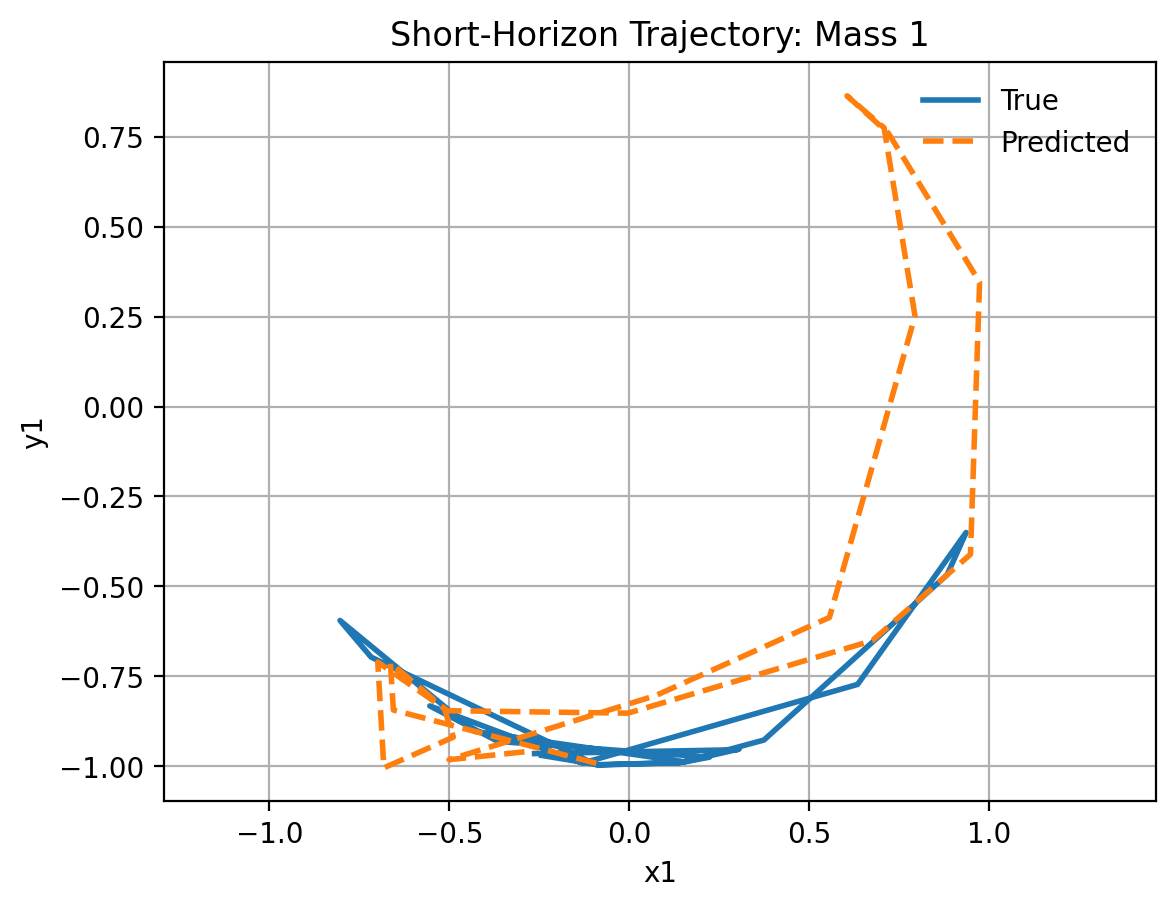

In [ ]:
# Plotting of True vs Predicted Trajectories for Mass 1
plt.figure()
plt.plot(true_x1, true_y1, label='True', linewidth=2)
plt.plot(pred_x1, pred_y1, '--', label='Predicted', linewidth=2)
plt.xlabel('x1')
plt.ylabel('y1')
plt.title('Short‑Horizon Trajectory: Mass 1')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


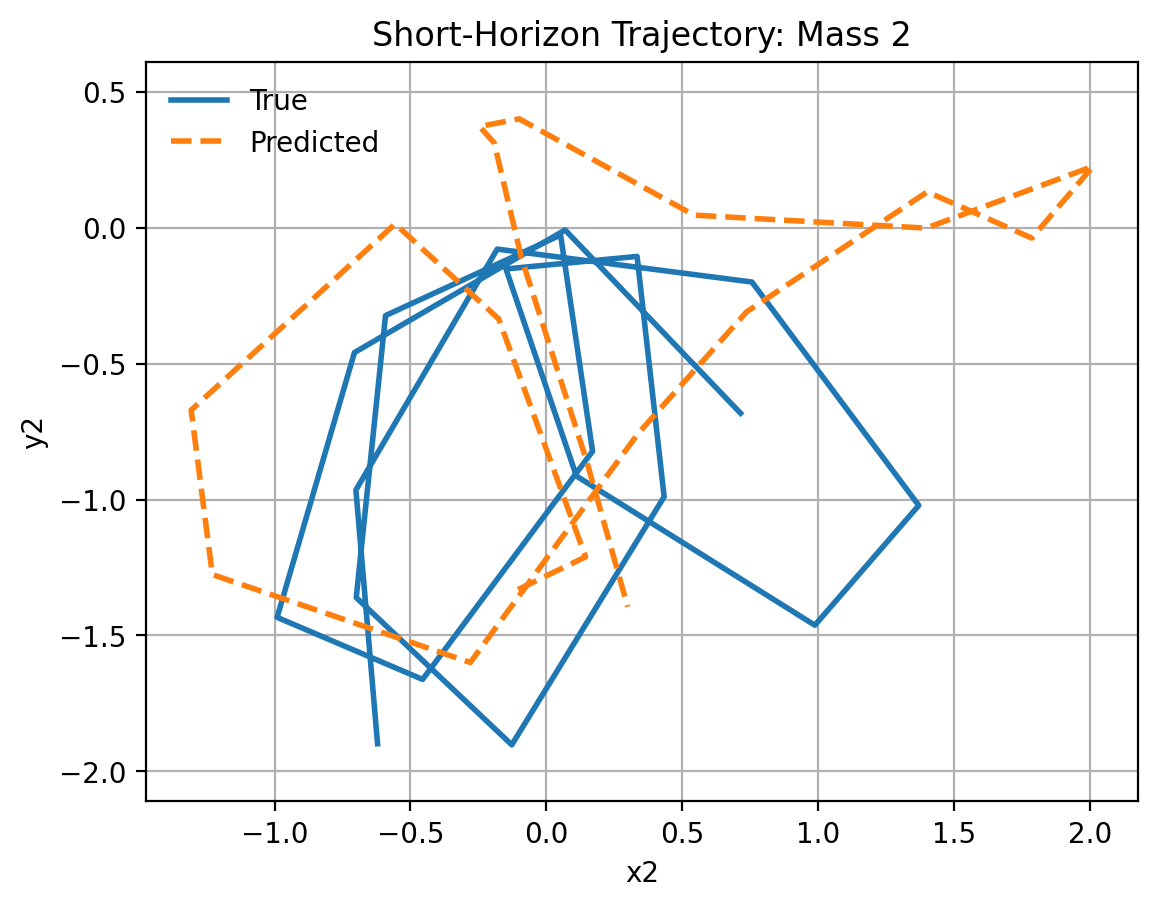

In [ ]:
# Plotting of True vs Predicted Trajectories for Mass 2
plt.figure()
plt.plot(true_x2, true_y2, label='True', linewidth=2)
plt.plot(pred_x2, pred_y2, '--', label='Predicted', linewidth=2)
plt.xlabel('x2')
plt.ylabel('y2')
plt.title('Short‑Horizon Trajectory: Mass 2')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


**Visualising Deviations**

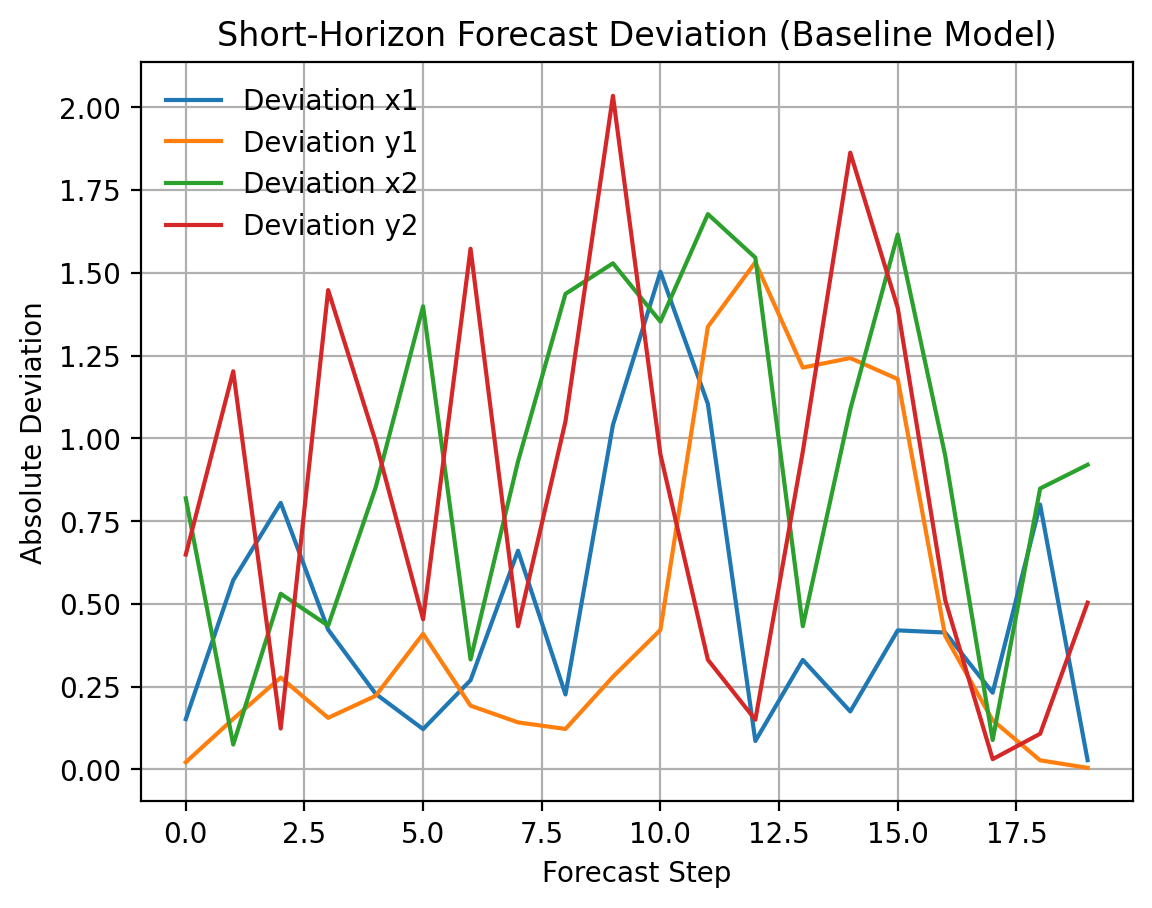

In [ ]:
# Calculate deviations for each coordinate
dev_x1 = np.abs(pred_x1 - true_x1)
dev_y1 = np.abs(pred_y1 - true_y1)
dev_x2 = np.abs(pred_x2 - true_x2)
dev_y2 = np.abs(pred_y2 - true_y2)

# Plot deviation curves
plt.figure()
plt.plot(t_future, dev_x1, label='Deviation x1')
plt.plot(t_future, dev_y1, label='Deviation y1')
plt.plot(t_future, dev_x2, label='Deviation x2')
plt.plot(t_future, dev_y2, label='Deviation y2')
plt.xlabel('Forecast Step')
plt.ylabel('Absolute Deviation')
plt.title('Short‑Horizon Forecast Deviation (Baseline Model)')
plt.legend()
plt.grid(True)
plt.show()


Over the 20‑step horizon, the baseline model tracks the true motion reasonably well for both masses. The predicted trajectories follow the correct geometric structure, and divergence remains modest across the short rollout. This behaviour reflects the model’s ability to capture local dynamics before autoregressive error accumulation becomes significant. The deviation curves show this clearly: errors stay low initially and increase gradually, consistent with the early‑stage behaviour of a chaotic system where small inaccuracies have not yet amplified.

# Long‑Horizon Forecasting

A 100‑step forecast horizon is chosen to clearly expose the growth of prediction
error in the chaotic regime while remaining close enough to the training horizon
to allow meaningful comparison between models. Longer horizons (150–200 steps)
tend to saturate the deviation curves and make interpretation less clear, while
shorter horizons do not fully reveal the onset of divergence.


**Forecast Preparation**

In [ ]:
# Long-horizon prediction (100 steps)

# Choose test sequence and long true future values
initial_seq = X_test[-1]
true_future_long = y_test[-100:]

# Predict the next 100 steps
pred_future_long_scaled = predict_future_positions(
    model,
    initial_seq,
    n_steps=100,
    seq_len=seq_len
)

# Unscale both true and predicted values
pred_future_long = pred_future_long_scaled * max_vals
true_future_long_unscaled = true_future_long * max_vals

# Extract positions
true_x1_L, true_y1_L = true_future_long_unscaled[:, 0], true_future_long_unscaled[:, 1]
true_x2_L, true_y2_L = true_future_long_unscaled[:, 2], true_future_long_unscaled[:, 3]

pred_x1_L, pred_y1_L = pred_future_long[:, 0], pred_future_long[:, 1]
pred_x2_L, pred_y2_L = pred_future_long[:, 2], pred_future_long[:, 3]

# Time axis for 100-step forecast
t_long = np.arange(100)


**Visualising True vs Predicted Trajectories**

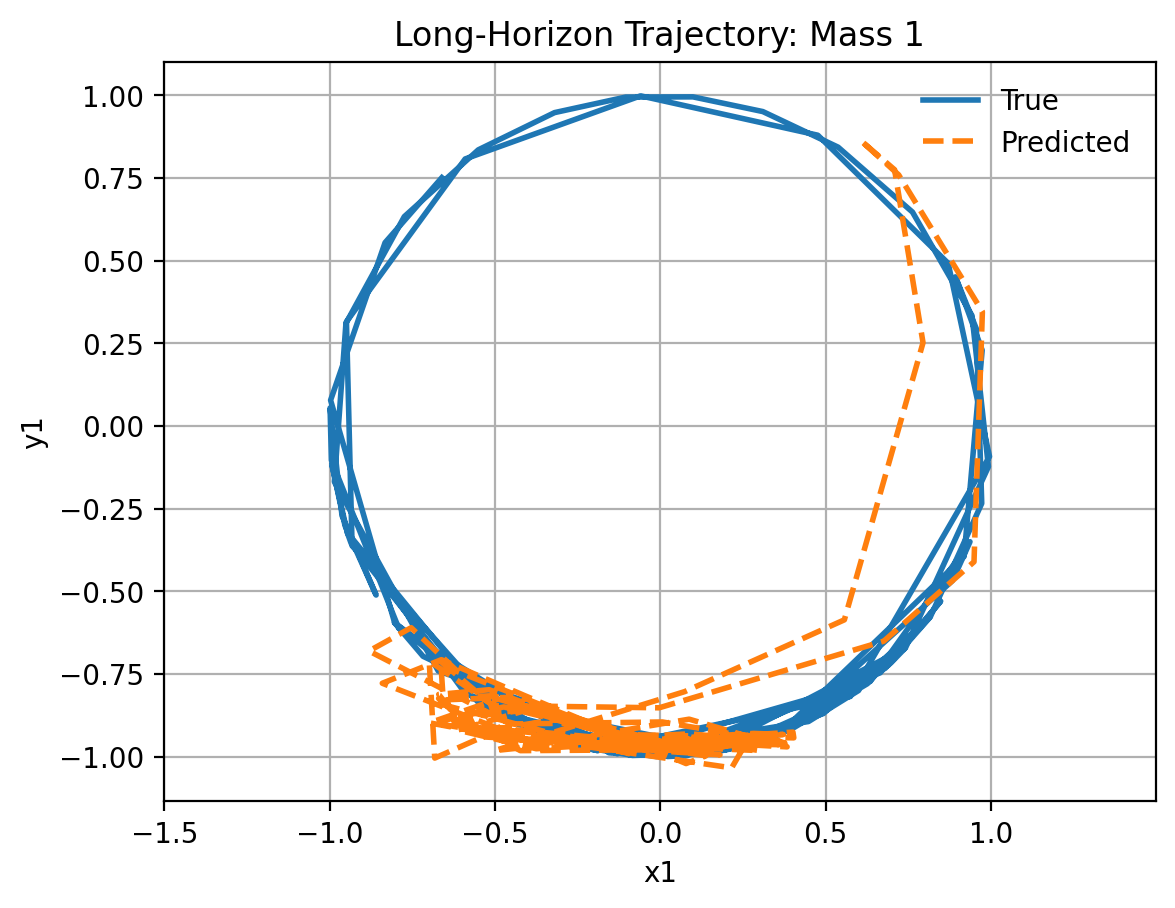

In [ ]:
# Plotting of True vs Predicted Trajectories for Mass 1
plt.figure()
plt.plot(true_x1_L, true_y1_L, label='True', linewidth=2)
plt.plot(pred_x1_L, pred_y1_L, '--', label='Predicted', linewidth=2)
plt.xlabel('x1')
plt.ylabel('y1')
plt.title('Long‑Horizon Trajectory: Mass 1')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


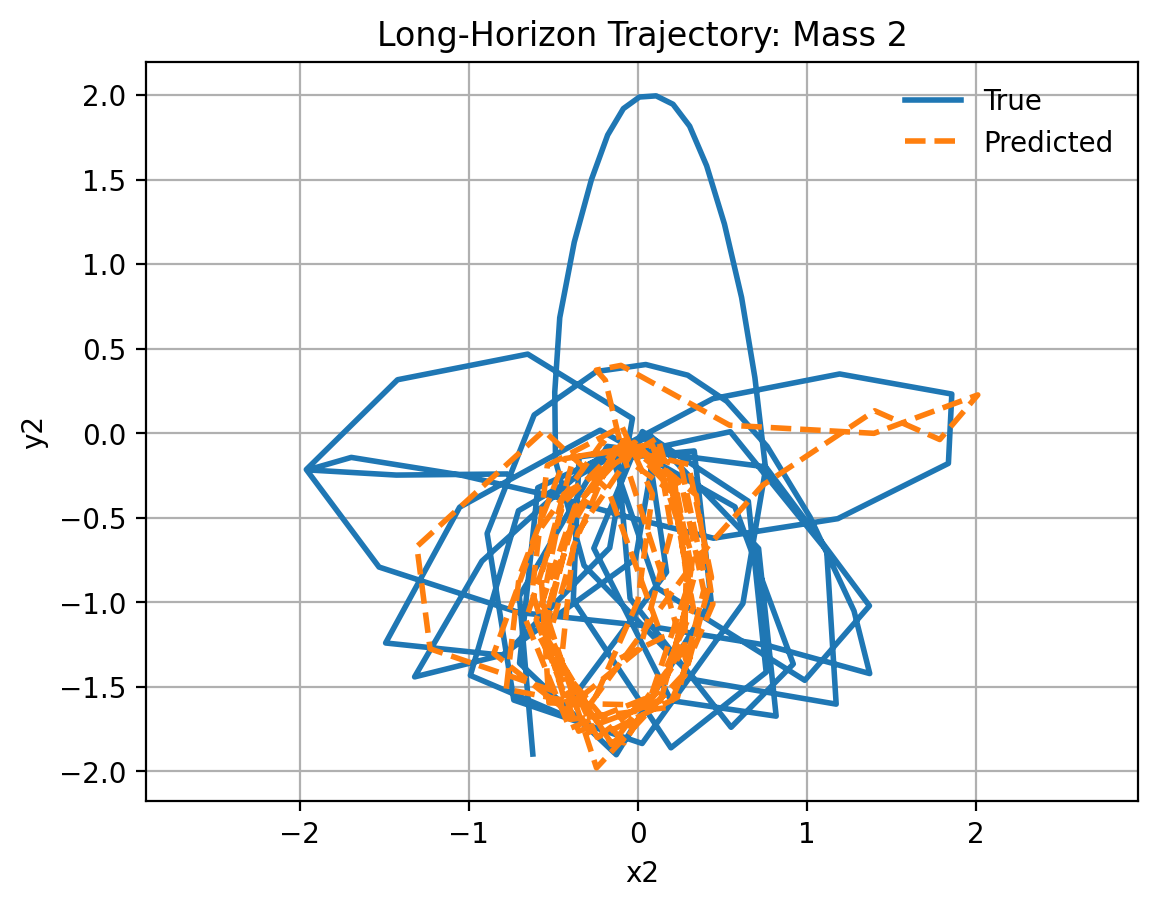

In [ ]:
# Plotting of True vs Predicted Trajectories for Mass 2
plt.figure()
plt.plot(true_x2_L, true_y2_L, label='True', linewidth=2)
plt.plot(pred_x2_L, pred_y2_L, '--', label='Predicted', linewidth=2)
plt.xlabel('x2')
plt.ylabel('y2')
plt.title('Long‑Horizon Trajectory: Mass 2')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


**Visualising Deviations**

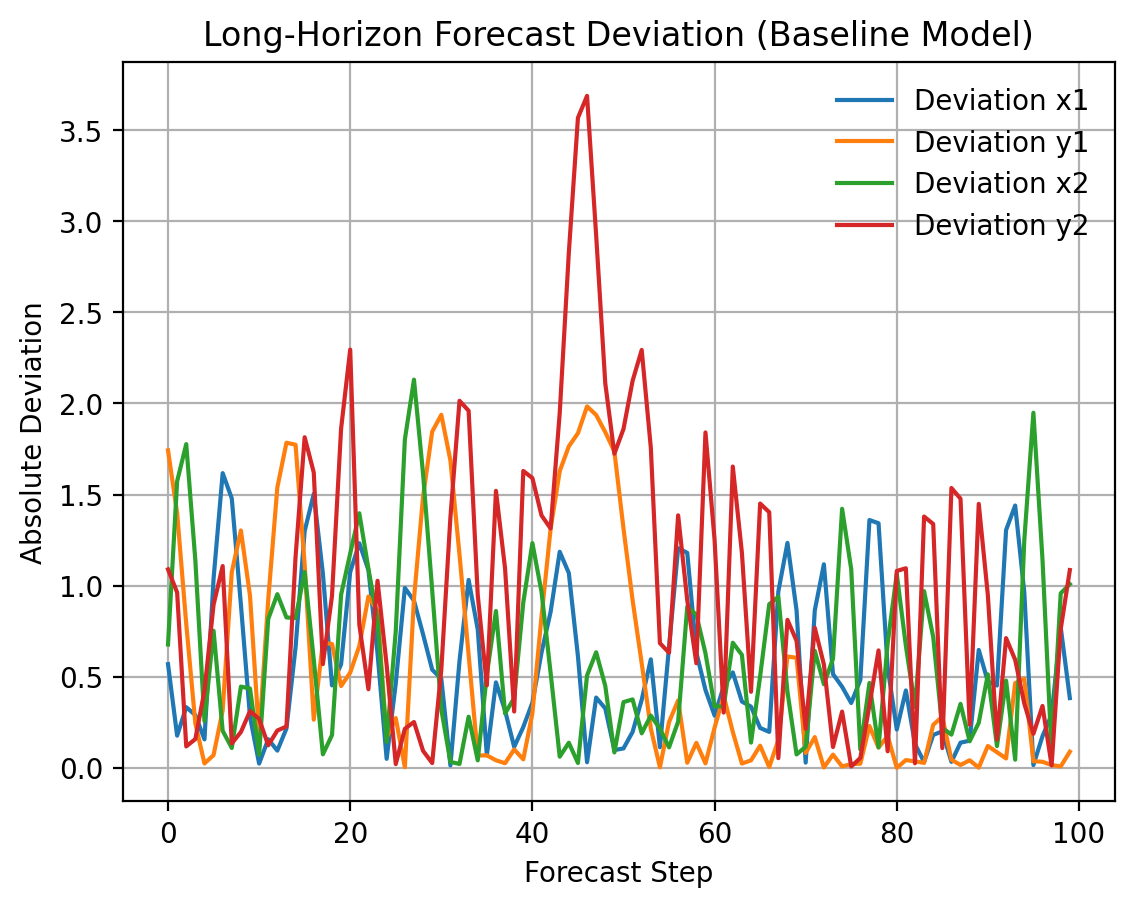

In [ ]:
# Calculate deviations
dev_x1_L = np.abs(pred_x1_L - true_x1_L)
dev_y1_L = np.abs(pred_y1_L - true_y1_L)
dev_x2_L = np.abs(pred_x2_L - true_x2_L)
dev_y2_L = np.abs(pred_y2_L - true_y2_L)

# Plot deviation curves
plt.figure()
plt.plot(t_long, dev_x1_L, label='Deviation x1')
plt.plot(t_long, dev_y1_L, label='Deviation y1')
plt.plot(t_long, dev_x2_L, label='Deviation x2')
plt.plot(t_long, dev_y2_L, label='Deviation y2')
plt.xlabel('Forecast Step')
plt.ylabel('Absolute Deviation')
plt.title('Long‑Horizon Forecast Deviation (Baseline Model)')
plt.legend()
plt.grid(True)
plt.show()

Over the 100‑step horizon, the baseline model fails to maintain coherent trajectories for either mass. The predicted paths initially resemble the true motion but diverge sharply as the rollout progresses, reflecting the rapid amplification of small state‑space errors in a chaotic system. Once the model begins propagating its own predictions, inaccuracies compound exponentially, causing the predicted trajectories to peel away from the true orbits and lose physical plausibility. The deviation curves capture this behaviour quantitatively: errors remain moderate in the early part of the rollout but grow rapidly across the horizon, illustrating the model’s inability to sustain stable long‑range forecasts without additional physical structure.

# Physics‑Informed Loss

Purely data‑driven models do not enforce any physical structure on the learned dynamics, which limits their stability when forecasting chaotic systems. For the double pendulum, one key physical property is the approximate conservation of total mechanical energy in the absence of damping. To incorporate this principle, a physics‑informed loss term is added that penalises discrepancies in total energy between successive predicted states. The total loss combines the standard data‑driven term (mean squared error) with an energy‑based regularisation penalty, encouraging predictions that remain physically consistent. This aims to improve long‑term stability while preserving the short‑term accuracy achieved by the baseline model.

**Energy Function (Cartesian Formulation) :**

In [ ]:
# Convert the existing max_vals array to a TensorFlow tensor for unscaling
max_vals_tf = tf.constant(max_vals, dtype=tf.float32)

def total_energy_cartesian(state_unscaled):
    """
    Calculate an approximate total mechanical energy from Cartesian state.
    state_unscaled: (..., 8) tensor of [x1, y1, x2, y2, vx1, vy1, vx2, vy2]
    """
    x1, y1, x2, y2, vx1, vy1, vx2, vy2 = tf.unstack(state_unscaled, axis=-1)

    # Kinetic energy
    KE1 = 0.5 * m1 * (vx1**2 + vy1**2)
    KE2 = 0.5 * m2 * (vx2**2 + vy2**2)
    KE  = KE1 + KE2

    # Potential energy (y is height)
    PE1 = m1 * g * y1
    PE2 = m2 * g * y2
    PE  = PE1 + PE2

    return KE + PE


**Physics Informed Loss Function :**

In [ ]:
# Define physics informed loss function

def physics_informed_loss(y_true, y_pred):
    """
    Physics-informed loss combining data MSE and an energy-based regularisation term.

    y_true, y_pred: (..., 8) states scaled by elementwise division with max_vals.
    """

    # Data term (standard MSE in scaled space)
    data_term = tf.reduce_mean(tf.square(y_true - y_pred))

    # Physics term (energy consistency in unscaled space):

    # Unscale to physical units
    y_true_unscaled = y_true * max_vals_tf
    y_pred_unscaled = y_pred * max_vals_tf

    # Calculate energies
    E_true = total_energy_cartesian(y_true_unscaled)
    E_pred = total_energy_cartesian(y_pred_unscaled)

    # Penalise energy mismatch
    phys_term = tf.reduce_mean(tf.square(E_pred - E_true))

    # Output total loss where lamda_phys is weight for physics term
    return data_term + lambda_phys * phys_term


**Scaling the Physics Term:**

The data‑driven loss and the energy‑based regularisation term operate on different numerical scales. To ensure that both components contribute meaningfully during optimisation, their relative magnitudes are estimated on a small validation batch. This provides a scale‑appropriate weighting for the physics term and avoids regimes where it is either negligible or dominant.

In [ ]:
# Estimate the relative scales of the data term and physics term

# Select a small batch from the validation set
batch_X = X_valid[:64]
batch_y = y_valid[:64]

# Forward pass through the current model
y_pred_batch = model(batch_X)

# Data term (MSE in scaled space)
data_term_val = tf.reduce_mean(tf.square(batch_y - y_pred_batch))


# Physics term (energy mismatch in physical units) :

# Unscale states back to physical units
y_true_unscaled = batch_y * max_vals_tf
y_pred_unscaled = y_pred_batch * max_vals_tf

# Calculate total mechanical energy for true and predicted states
E_true_val = total_energy_cartesian(y_true_unscaled)
E_pred_val = total_energy_cartesian(y_pred_unscaled)

# Energy residual (squared difference)
phys_term_val = tf.reduce_mean(tf.square(E_pred_val - E_true_val))

# Display the relative magnitudes of the two components
print("Data term scale:   ", float(data_term_val))
print("Energy term scale: ", float(phys_term_val))


Data term scale:    0.0014163140440359712
Energy term scale:  2.0109779834747314


In [ ]:
# Caclculate a scale‑matched weighting for the physics term
lambda_phys = float(data_term_val / phys_term_val)
print("Suggested lambda_phys:", lambda_phys)


Suggested lambda_phys: 0.0007042911602184176


The scale‑matching diagnostic yields a λ_phys value on the order of 10⁻³–10⁻⁴, which is then used as the weighting for the physics term during training.

**Physics‑Informed Model Architecture :**

The physics‑informed model uses the same architecture as the baseline model; only the training objective is modified through the inclusion of the energy‑based regularisation term.

In [ ]:
# Recurrent neural network for short‑term forecasting
model_phys= keras.models.Sequential()

# Input layer: sequences of length 50 with 8 features per timestep
model_phys.add(keras.layers.Input(shape=(seq_len, 8)))

# LSTM layer: extracts temporal structure from the input sequence
model_phys.add(keras.layers.LSTM(
    64,
    activation='tanh',
    return_sequences=False
))

# Regularisation to improve generalisation on chaotic dynamics
model_phys.add(keras.layers.Dropout(0.2))

# Fully‑connected layers to map the LSTM state to the output space
model_phys.add(keras.layers.Dense(64, activation='tanh'))
model_phys.add(keras.layers.Dropout(0.2))
model_phys.add(keras.layers.Dense(32, activation='tanh'))

# Output layer: predict the next state (8 values)
model_phys.add(keras.layers.Dense(8, activation='linear'))

# Compile the model
model_phys.compile(
    optimizer='adam',
    loss=physics_informed_loss,
    metrics=['mean_absolute_error']
)



# Display model summary
model_phys.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,192 (98.41 KB)

 Trainable params: 25,192 (98.41 KB)

 Non-trainable params: 0 (0.00 B)

**Training Physics Informed Model :**

The physics‑informed model is trained using the same optimisation settings as the baseline model, with the loss now incorporating the energy‑based regularisation term.

In [ ]:
history_phys = model_phys.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),  # Parameter setting consistent
    epochs=200,                          # with baseline model, i.e
    batch_size=32,                       # use the same values for :
    shuffle=False,                       # epochs, batch_size,
    callbacks=[early_stop],              # shuffle and callbacks.
    verbose=1
)

Epoch 1/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.3520 - mean_absolute_error: 0.3127 - val_loss: 0.1266 - val_mean_absolute_error: 0.2163
Epoch 2/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.1944 - mean_absolute_error: 0.2526 - val_loss: 0.0668 - val_mean_absolute_error: 0.1590
Epoch 3/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1490 - mean_absolute_error: 0.2230 - val_loss: 0.0469 - val_mean_absolute_error: 0.1339
Epoch 4/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.1237 - mean_absolute_error: 0.2033 - val_loss: 0.0383 - val_mean_absolute_error: 0.1197
Epoch 5/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1136 - mean_absolute_error: 0.1918 - val_loss: 0.0275 - val_mean_absolute_error: 0.1077
Epoch 6/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0998 - mean_absolute_error: 0.1814 - val_loss: 0.0250 - val_mean_absolute_error: 0.1024
Epoch 7/200
226/226 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0959 - mean_absolute_err

# Physics Informed Model Evaluation

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.3388 - mean_absolute_error: 0.3328
Test Loss: 0.3388,  Mean Absolute Error: 0.3328


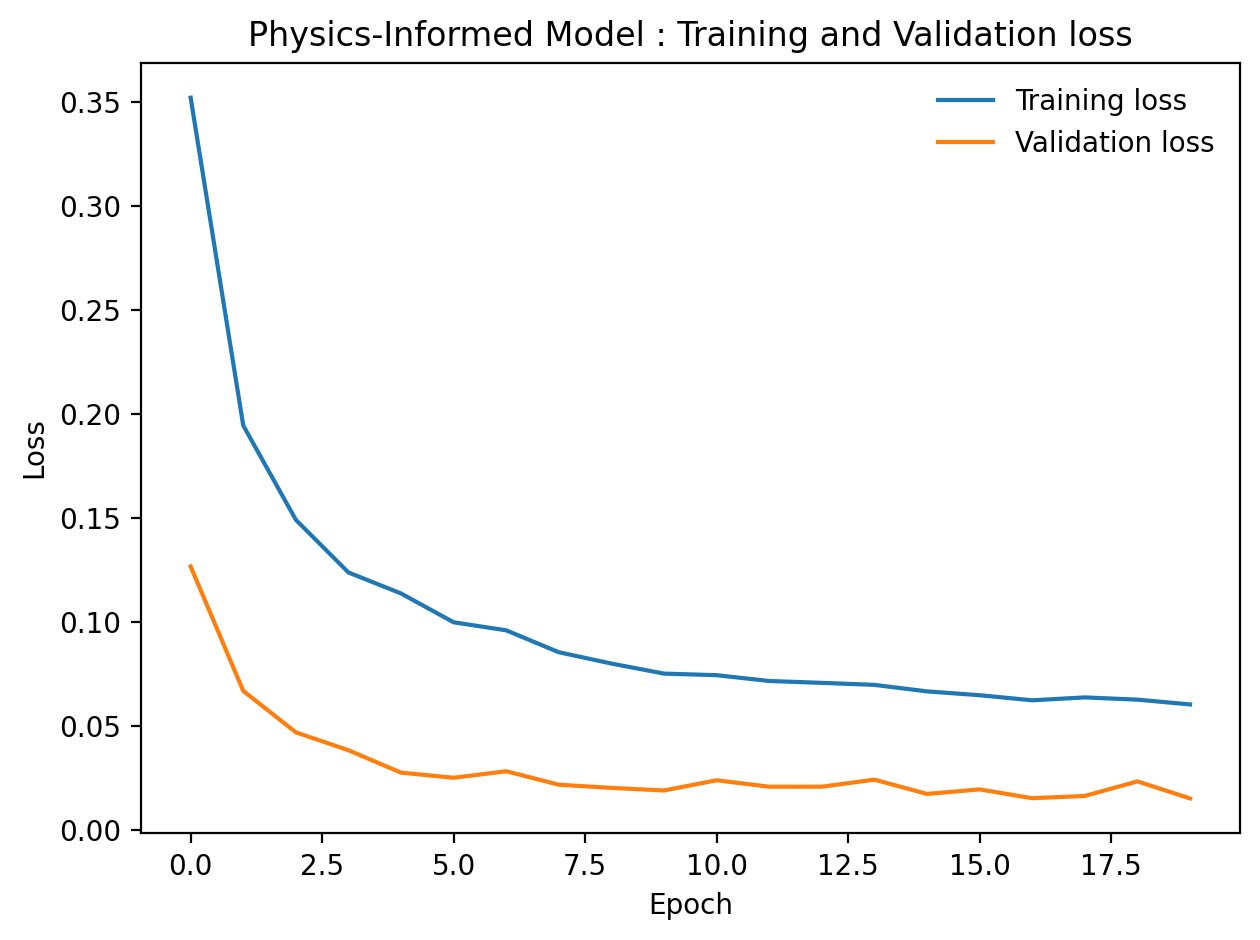

In [ ]:
# Evaluate model on the test set
test_loss, test_mae = model_phys.evaluate(X_test, y_test, verbose=1)

# Plot training and validation loss curve
print(f"Test Loss: {test_loss:.4f},  Mean Absolute Error: {test_mae:.4f}")
plt.figure()
plt.plot(history_phys.history['loss'], label='Training loss')
plt.plot(history_phys.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Physics-Informed Model : Training and Validation loss')
plt.legend()
plt.tight_layout()
plt.show()


The physics‑informed model converges quickly, with the validation loss settling early due to the regularising influence of the energy‑based term, which constrains the optimisation landscape and promotes stable training dynamics.

# Physics Informed Short-Horizon Forecasting

**Forecast Preparation :**

In [ ]:
## Short‑Horizon Forecasting (Physics‑Informed Model)

# Select a test sequence (same as baseline)
initial_seq = X_test[-1]          # shape (seq_len, 8)
true_future = y_test[-20:]         # next 20 true steps

# Predict 20 future steps autoregressively
pred_future_scaled = predict_future_positions(
    model_phys,                        # physics‑informed model
    initial_seq,
    n_steps=20,
    seq_len=seq_len
)

# Unscale both predicted and true states
pred_future = pred_future_scaled * max_vals
true_future_unscaled = true_future * max_vals


# Extract Cartesian positions
true_x1, true_y1 = true_future_unscaled[:, 0], true_future_unscaled[:, 1]
true_x2, true_y2 = true_future_unscaled[:, 2], true_future_unscaled[:, 3]

pred_x1, pred_y1 = pred_future[:, 0], pred_future[:, 1]
pred_x2, pred_y2 = pred_future[:, 2], pred_future[:, 3]

# Time axis for 20‑step forecast
t_future = np.arange(20)


In [ ]:
# TEST PRINT BLOCK TO CHECK PREDICTIONS ARE HAPPENING CORRECTLY

# Print predicted states
def show_future_positions(unscaled_states):
    for i, state in enumerate(unscaled_states):
        print(f"t = t0 + {(i+1)}Δt : {state}")

show_future_positions(true_future_unscaled)

t = t0 + 1Δt : [-0.17931698 -0.98379135 -0.40260985 -0.00903995  4.53624297 -0.82682714
  4.31740768 -0.87695722]
t = t0 + 2Δt : [ 3.14097083e-01 -9.49390869e-01 -7.37949681e-03 -2.47333916e-03
  4.87589124e+00  1.61314298e+00  3.49602509e+00  1.14468122e+00]
t = t0 + 3Δt : [ 0.71347729 -0.70067836  0.28751039  0.20406039  2.92391705  2.97732672
  2.44156023  2.75022466]
t = t0 + 4Δt : [ 0.90900757 -0.41677961  0.50021682  0.49584853  1.15870507  2.52716703
  1.91986659  2.86811179]
t = t0 + 5Δt : [ 0.97815478 -0.20787791  0.68589971  0.74846249  0.34969496  1.64546485
  1.83212991  2.098493  ]
t = t0 + 6Δt : [ 0.99626851 -0.08630789  0.86991839  0.90567782  0.06890916  0.79543165
  1.8503757   1.02233866]
t = t0 + 7Δt : [ 9.98872631e-01 -4.74707011e-02  1.05558729e+00  9.50919727e-01
 -8.21483552e-04 -1.72855555e-02  1.85568060e+00 -1.22746189e-01]
t = t0 + 8Δt : [ 0.99600382 -0.08931066  1.24017001  0.88042274 -0.07254153 -0.80899239
  1.82784331 -1.28748444]
t = t0 + 9Δt : [ 0.97850

**Visualising True vs Predicted Trajectories**

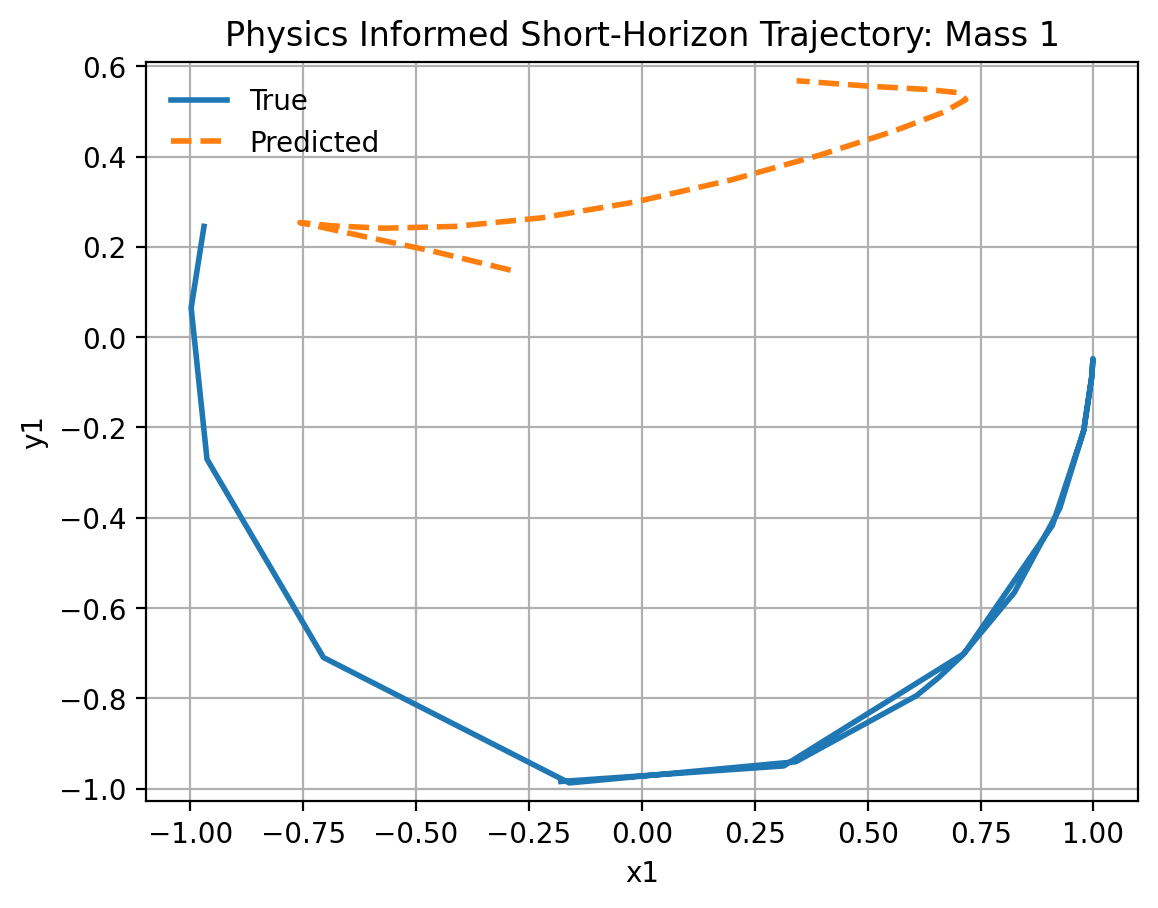

In [ ]:
# Plotting of True vs Predicted Trajectories for Mass 1
plt.figure()
plt.plot(true_x1, true_y1, label='True', linewidth=2)
plt.plot(pred_x1, pred_y1, '--', label='Predicted', linewidth=2)
plt.xlabel('x1')
plt.ylabel('y1')
plt.title('Physics Informed Short‑Horizon Trajectory: Mass 1')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

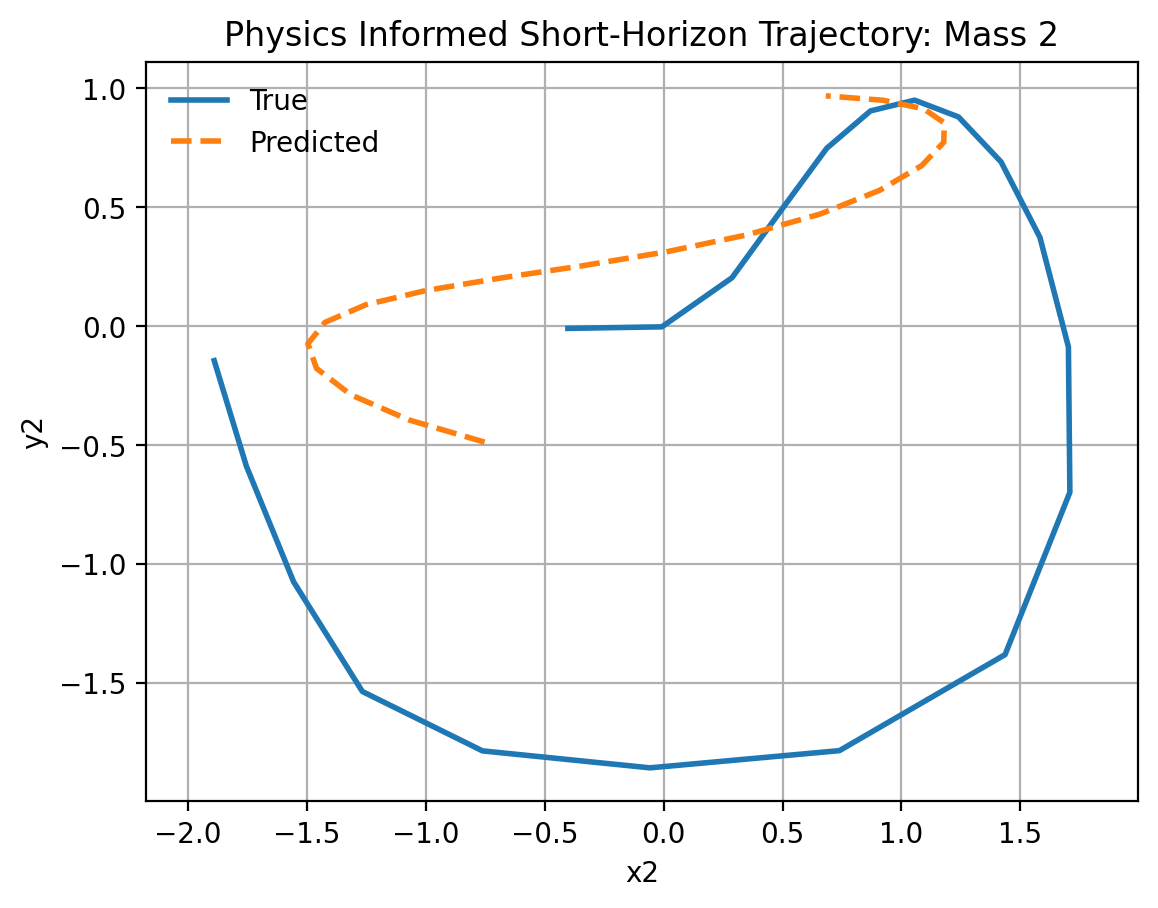

In [ ]:
# Plotting of True vs Predicted Trajectories for Mass 2
plt.figure()
plt.plot(true_x2, true_y2, label='True', linewidth=2)
plt.plot(pred_x2, pred_y2, '--', label='Predicted', linewidth=2)
plt.xlabel('x2')
plt.ylabel('y2')
plt.title('Physics Informed Short‑Horizon Trajectory: Mass 2')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

**Visualising Deviations**

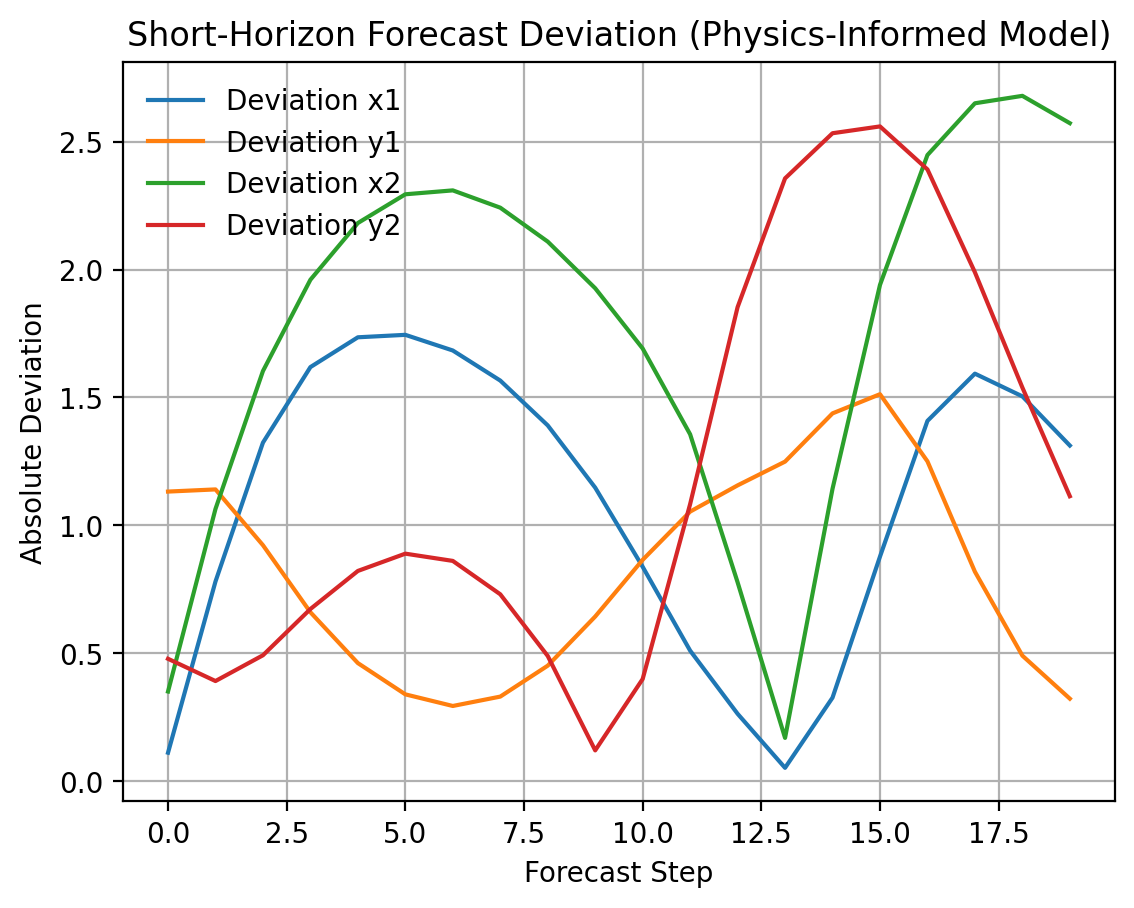

In [ ]:
# Calculate deviations for each coordinate
dev_x1 = np.abs(pred_x1 - true_x1)
dev_y1 = np.abs(pred_y1 - true_y1)
dev_x2 = np.abs(pred_x2 - true_x2)
dev_y2 = np.abs(pred_y2 - true_y2)

# Plot deviation curves
plt.figure()
plt.plot(t_future, dev_x1, label='Deviation x1')
plt.plot(t_future, dev_y1, label='Deviation y1')
plt.plot(t_future, dev_x2, label='Deviation x2')
plt.plot(t_future, dev_y2, label='Deviation y2')
plt.xlabel('Forecast Step')
plt.ylabel('Absolute Deviation')
plt.title('Short‑Horizon Forecast Deviation (Physics-Informed Model)')
plt.legend()
plt.grid(True)
plt.show()


The physics‑informed model preserves the qualitative structure of the short‑term trajectories but exhibits a consistent positional offset, with the predicted paths tracing the correct oscillatory shape while remaining displaced from the true coordinates. The deviation curves show low‑amplitude, oscillatory errors in the x‑coordinates and smoother, lower‑frequency deviations in the y‑coordinates, reflecting the different dynamic ranges of horizontal and vertical motion. Overall, the model captures the underlying dynamics but prioritises physical consistency over exact positional alignment, leading to structured but shifted short‑horizon predictions.

# Physics Informed Long Horizon Forecasting

**Forecast Preparation**

The physics‑informed model is rolled out autoregressively for 100 steps to assess long‑range stability and structural consistency.

In [ ]:
# Long-horizon prediction (100 steps)

# Choose test sequence and long true future values
initial_seq = X_test[-1]
true_future_long = y_test[-100:]

# Predict the next 100 steps
pred_future_long_scaled = predict_future_positions(
    model_phys,
    initial_seq,
    n_steps=100,
    seq_len=seq_len
)

# Unscale both true and predicted values
pred_future_long = pred_future_long_scaled * max_vals
true_future_long_unscaled = true_future_long * max_vals

# Extract positions
true_x1_L, true_y1_L = true_future_long_unscaled[:, 0], true_future_long_unscaled[:, 1]
true_x2_L, true_y2_L = true_future_long_unscaled[:, 2], true_future_long_unscaled[:, 3]

pred_x1_L, pred_y1_L = pred_future_long[:, 0], pred_future_long[:, 1]
pred_x2_L, pred_y2_L = pred_future_long[:, 2], pred_future_long[:, 3]

# Time axis for 100-step forecast
t_long = np.arange(100)


**Visualising True vs Predicted Trajectories :**

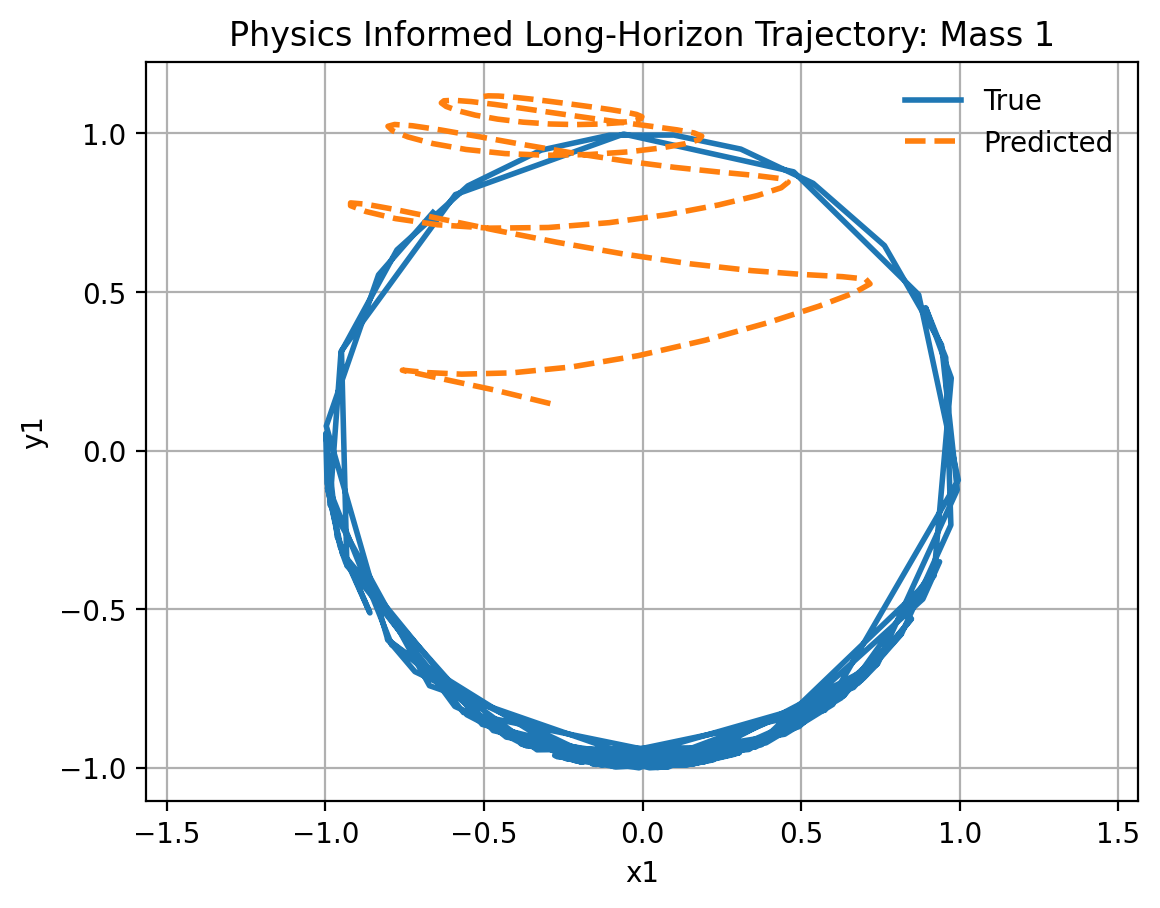

In [ ]:
# Plotting of True vs Predicted Trajectories for Mass 1
plt.figure()
plt.plot(true_x1_L, true_y1_L, label='True', linewidth=2)
plt.plot(pred_x1_L, pred_y1_L, '--', label='Predicted', linewidth=2)
plt.xlabel('x1')
plt.ylabel('y1')
plt.title('Physics Informed Long‑Horizon Trajectory: Mass 1')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

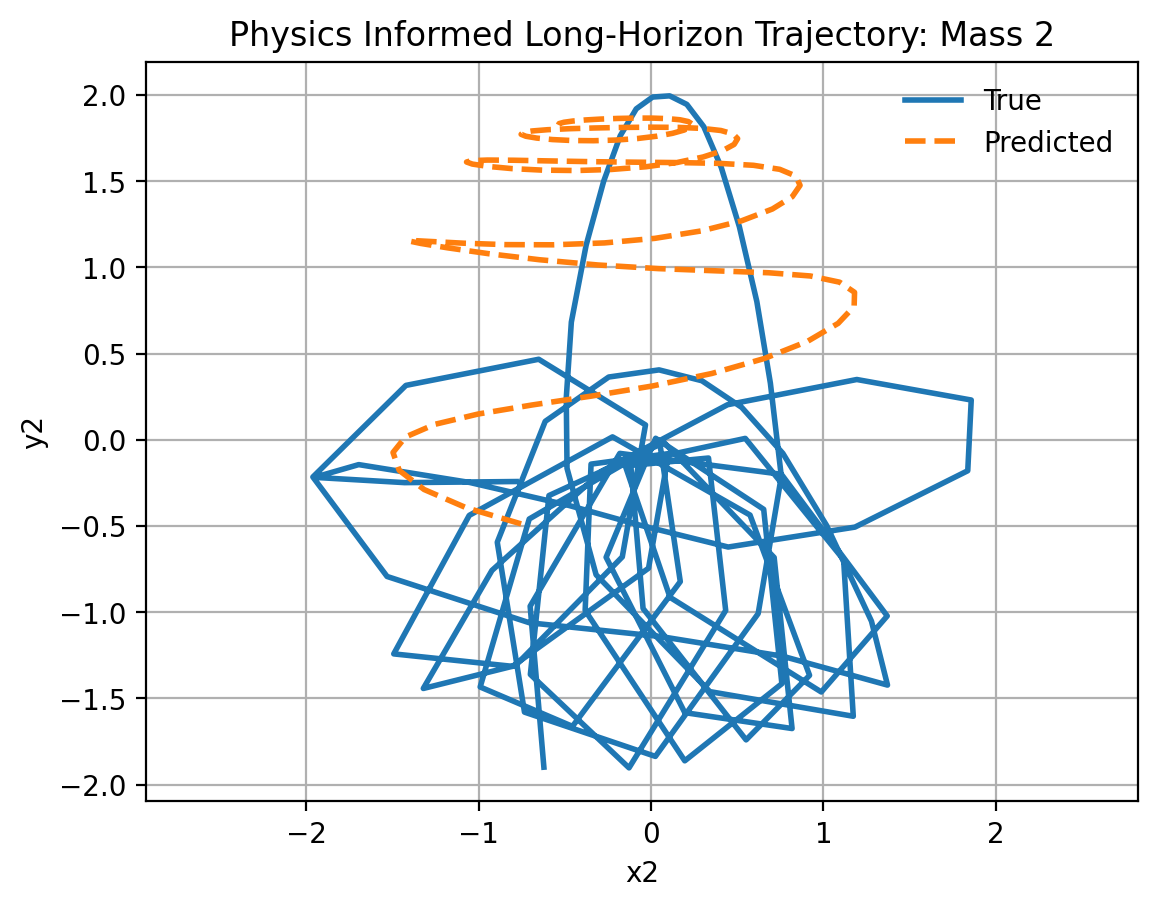

In [ ]:
# Plotting of True vs Predicted Trajectories for Mass 2
plt.figure()
plt.plot(true_x2_L, true_y2_L, label='True', linewidth=2)
plt.plot(pred_x2_L, pred_y2_L, '--', label='Predicted', linewidth=2)
plt.xlabel('x2')
plt.ylabel('y2')
plt.title('Physics Informed Long‑Horizon Trajectory: Mass 2')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

**Visualising Deviations :**

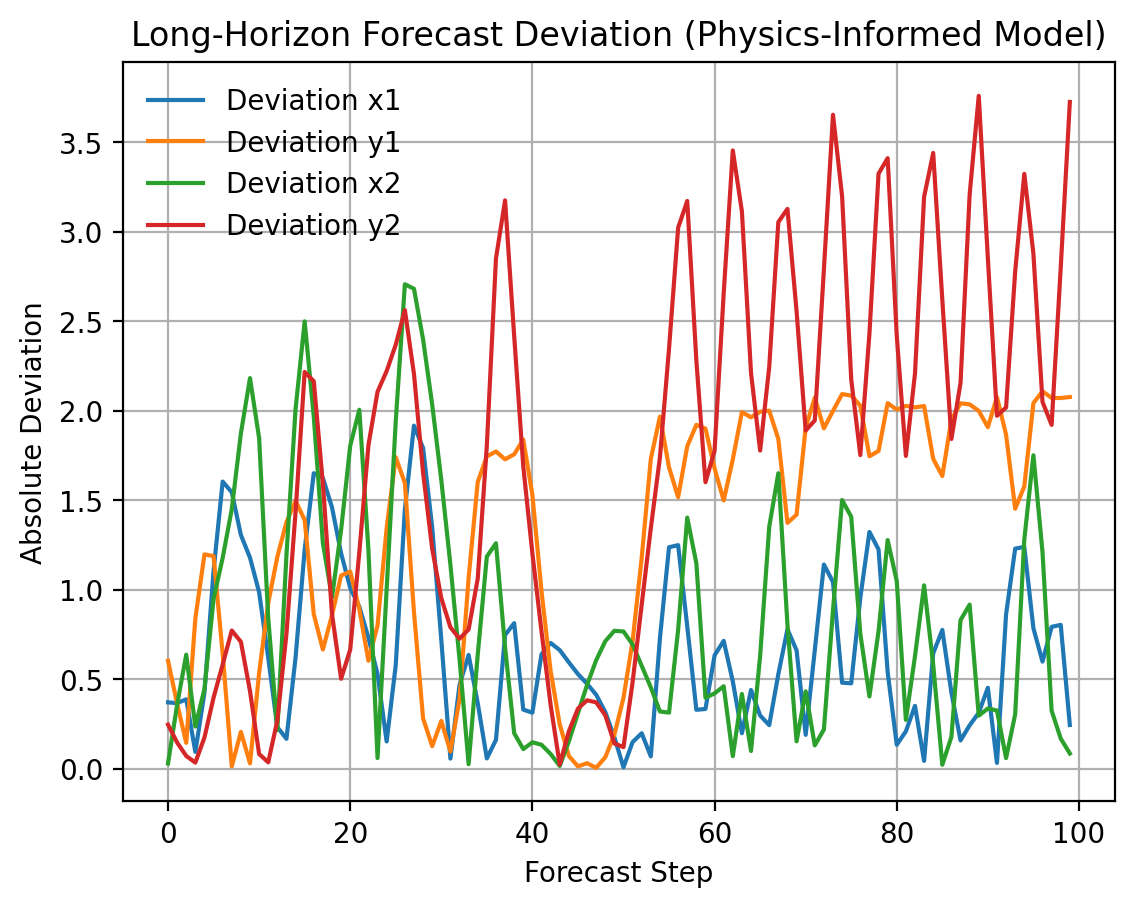

In [ ]:
# Calculate deviations for each coordinate
dev_x1_L = np.abs(pred_x1_L - true_x1_L)
dev_y1_L = np.abs(pred_y1_L - true_y1_L)
dev_x2_L = np.abs(pred_x2_L - true_x2_L)
dev_y2_L = np.abs(pred_y2_L - true_y2_L)

# Plot deviation curves
plt.figure()
plt.plot(t_long, dev_x1_L, label='Deviation x1')
plt.plot(t_long, dev_y1_L, label='Deviation y1')
plt.plot(t_long, dev_x2_L, label='Deviation x2')
plt.plot(t_long, dev_y2_L, label='Deviation y2')
plt.xlabel('Forecast Step')
plt.ylabel('Absolute Deviation')
plt.title('Long‑Horizon Forecast Deviation (Physics-Informed Model)')
plt.legend()
plt.grid(True)
plt.show()

Over the 100-step rollout, the physics-informed model maintains coherent oscillatory structure for longer than the baseline, though the predicted paths become increasingly displaced and higher-frequency relative to the true trajectories. The deviation curves show the largest errors in the vertical coordinates, particularly y₂, consistent with the greater sensitivity of vertical motion to accumulated angular error. Horizontal deviations remain smaller and more regular throughout. The energy penalty therefore improves structural coherence at the cost of positional accuracy; the oscillatory shape is preserved while the absolute position drifts.

# Concluding Remarks

Across both short‑ and long‑horizon evaluations, the baseline and physics‑informed models exhibit distinct strengths and limitations. The baseline model achieves good short‑term alignment with the true trajectories but deteriorates rapidly once autoregressive errors accumulate, leading to unstable long‑range forecasts. In contrast, the physics‑informed model sacrifices exact positional accuracy in the short horizon but maintains more coherent dynamical structure, reflecting the stabilising influence of the physical constraint. Over long horizons, both models ultimately diverge due to the chaotic nature of the system, but the physics‑informed model retains physically plausible motion for longer before collapsing. These results highlight the trade‑off between local accuracy and structural consistency, and demonstrate the value of incorporating physical knowledge when forecasting chaotic dynamics.